In [64]:
# ==========================================================
# PID1
# Install Required Packages
# ==========================================================

import subprocess
import sys

try:
    import odf
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "odfpy", "--user"])

In [65]:
# ==========================================================
# PID2
# Import Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("="*60)
print("Notebook 11")
print("Dietary Feature Engineering and Food Pattern Analysis")
print("="*60)

Notebook 11
Dietary Feature Engineering and Food Pattern Analysis


In [66]:
# ==========================================================
# PID3
# Load ML Dataset
# ==========================================================

master = pd.read_csv(
    "C:/Users/kalya/NTCC/NHANES/CVD_ML_python/Outputs/ML_ready_dataset.csv"
)

print("="*60)
print("ML Dataset Loaded")
print("="*60)

print("Shape :", master.shape)

master.head()

ML Dataset Loaded
Shape : (15457, 643)


,SEQN,SDMVPSU,SDMVSTRA,WTINTPRP,WTMECPRP,RIAGENDR,RIDAGEYR,RIDRETH1,RIDRETH3,DMDEDUC2,DMDMARTZ,INDFMPIR,MCQ160A,MCQ160M,MCQ160P,MCQ160L,BPQ020,BPQ030,BPQ040A,BPQ050A,BPQ080,BPQ090D,BPQ100D,BPXOSY1,BPXOSY2,BPXOSY3,BPXODI1,BPXODI2,BPXODI3,LBXGLU,LBXGH,LBXIN,LBXTC,LBDLDL,LBDHDD,LBXTR,BMXWT,BMXHT,BMXBMI,BMXWAIST,BMXHIP,DR1TNUMF,DR1TKCAL,DR1TPROT,DR1TCARB,DR1TSUGR,DR1TFIBE,DR1TTFAT,DR1TSFAT,DR1TMFAT,DR1TPFAT,DR1TCHOL,DR1TATOC,DR1TATOA,DR1TRET,DR1TVARA,DR1TACAR,DR1TBCAR,DR1TCRYP,DR1TLYCO,DR1TLZ,DR1TVB1,DR1TVB2,DR1TNIAC,DR1TVB6,DR1TFOLA,DR1TFA,DR1TFF,DR1TFDFE,DR1TCHL,DR1TVB12,DR1TB12A,DR1TVC,DR1TVD,DR1TVK,DR1TCALC,DR1TPHOS,DR1TMAGN,DR1TIRON,DR1TZINC,DR1TCOPP,DR1TSODI,DR1TPOTA,DR1TSELE,DR1TCAFF,DR1TTHEO,DR1TALCO,DR1TMOIS,DR1TS040,DR1TS060,DR1TS080,DR1TS100,DR1TS120,DR1TS140,DR1TS160,DR1TS180,DR1TM161,DR1TM181,DR1TM201,DR1TM221,DR1TP182,DR1TP183,DR1TP184,DR1TP204,DR1TP205,DR1TP225,DR1TP226,DR1TWSZ,DR2TNUMF,DR2TKCAL,DR2TPROT,DR2TCARB,DR2TSUGR,DR2TFIBE,DR2TTFAT,DR2TSFAT,DR2TMFAT,DR2TPFAT,DR2TCHOL,DR2TATOC,DR2TATOA,DR2TRET,DR2TVARA,DR2TACAR,DR2TBCAR,DR2TCRYP,DR2TLYCO,DR2TLZ,DR2TVB1,DR2TVB2,DR2TNIAC,DR2TVB6,DR2TFOLA,DR2TFA,DR2TFF,DR2TFDFE,DR2TCHL,DR2TVB12,DR2TB12A,DR2TVC,DR2TVD,DR2TVK,DR2TCALC,DR2TPHOS,DR2TMAGN,DR2TIRON,DR2TZINC,DR2TCOPP,DR2TSODI,DR2TPOTA,DR2TSELE,DR2TCAFF,DR2TTHEO,DR2TALCO,DR2TMOIS,DR2TS040,DR2TS060,DR2TS080,DR2TS100,DR2TS120,DR2TS140,DR2TS160,DR2TS180,DR2TM161,DR2TM181,DR2TM201,DR2TM221,DR2TP182,DR2TP183,DR2TP184,DR2TP204,DR2TP205,DR2TP225,DR2TP226,DR2TWSZ,DSQTKCAL,DSQTPROT,DSQTCARB,DSQTSUGR,DSQTFIBE,DSQTTFAT,DSQTSFAT,DSQTMFAT,DSQTPFAT,DSQTCHOL,DSQTLYCO,DSQTLZ,DSQTVB1,DSQTVB2,DSQTNIAC,DSQTVB6,DSQTFA,DSQTFDFE,DSQTCHL,DSQTVB12,DSQTVC,DSQTVK,DSQTVD,DSQTCALC,DSQTPHOS,DSQTMAGN,DSQTIRON,DSQTZINC,DSQTCOPP,DSQTSODI,DSQTPOTA,DSQTSELE,DSQTCAFF,DSQTIODI,SMQ020,SMD030,SMQ040,SMQ050Q,SMQ050U,SMD057,SMQ078,SMD641,SMD650,SMD100FL,SMD100MN,SMQ670,SMQ621,SMD630,SMD460,SMD470,SMQ681,SMQ690A,SMQ710,SMQ720,SMQ725,SMQ690B,SMQ740,SMQ690C,SMQ770,SMQ690G,SMQ845,SMQ690H,SMQ849,SMQ851,SMQ690D,SMQ800,SMQ690E,SMQ817,SMQ690K,SMQ863,SMQ690F,SMQ830,SMDANY,SMQ856,SMQ858,SMQ860,SMQ862,SMQ866,SMQ868,SMQ870,SMQ872,SMQ874,SMQ876,SMQ878,SMQ880,SMQ940,ALQ111,ALQ121,ALQ130,ALQ142,ALQ270,ALQ280,ALQ290,ALQ151,ALQ170,PAQ605,PAQ610,PAD615,PAQ620,PAQ625,PAD630,PAQ635,PAQ640,PAD645,PAQ650,PAQ655,PAD660,PAQ665,PAQ670,PAD675,PAD680,PAQ706,LBXCOT,LBXHCOT,URXBCPP,URXBCEP,URXBDCP,URXDBUP,URXDPHP,LBXBPB,LBXBCD,LBXTHG,LBXBSE,LBXBMN,LBXPFDE,LBXPFHS,LBXPFNA,LBXPFUA,LBXNFOA,LBXBFOA,LBXNFOS,LBXMFOS,URXUAS3,URXUAS5,URXUHG,URXUBA,URXUCD,URXUCO,URXUPB,URXUSB,URXUTL,URXUTU,URXUAS,MCQ300A,MCQ300B,MCQ300C,SMQ690A_WASMISSING,SMQ690B_WASMISSING,SMQ690C_WASMISSING,SMQ690G_WASMISSING,SMQ690H_WASMISSING,SMQ690D_WASMISSING,SMQ690E_WASMISSING,SMQ690K_WASMISSING,SMQ690F_WASMISSING,SMD030_WASMISSING,SMD057_WASMISSING,SMD641_WASMISSING,SMD650_WASMISSING,SMD100FL_WASMISSING,SMD100MN_WASMISSING,SMD630_WASMISSING,SMD460_WASMISSING,SMD470_WASMISSING,ALQ121_WASMISSING,ALQ130_WASMISSING,ALQ142_WASMISSING,ALQ270_WASMISSING,ALQ280_WASMISSING,ALQ290_WASMISSING,ALQ151_WASMISSING,ALQ170_WASMISSING,PAD615_WASMISSING,PAD630_WASMISSING,PAD645_WASMISSING,PAD660_WASMISSING,PAD675_WASMISSING,PAD680_WASMISSING,DSQTKCAL_WASMISSING,DSQTPROT_WASMISSING,DSQTCARB_WASMISSING,DSQTSUGR_WASMISSING,DSQTFIBE_WASMISSING,DSQTTFAT_WASMISSING,DSQTSFAT_WASMISSING,DSQTMFAT_WASMISSING,DSQTPFAT_WASMISSING,DSQTCHOL_WASMISSING,DSQTLYCO_WASMISSING,DSQTLZ_WASMISSING,DSQTVB1_WASMISSING,DSQTVB2_WASMISSING,DSQTNIAC_WASMISSING,DSQTVB6_WASMISSING,DSQTFA_WASMISSING,DSQTFDFE_WASMISSING,DSQTCHL_WASMISSING,DSQTVB12_WASMISSING,DSQTVC_WASMISSING,DSQTVK_WASMISSING,DSQTVD_WASMISSING,DSQTCALC_WASMISSING,DSQTPHOS_WASMISSING,DSQTMAGN_WASMISSING,DSQTIRON_WASMISSING,DSQTZINC_WASMISSING,DSQTCOPP_WASMISSING,DSQTSODI_WASMISSING,DSQTPOTA_WASMISSING,DSQTSELE_WASMISSING,DSQTCAFF_WASMISSING,DSQTIODI_WASMISSING,SMQ050Q_WASMISSING,SMQ050U_WASMISSING,SMQ078_WASMISSING,SMQ670_WASMISSING,SMQ710_WASMISSING,SMQ720_WASMISSING,SMQ725_WASMISSING,SMQ740_WASMISSING,SM

In [67]:
# ==========================================================
# PID4
# Load Food Dictionary
# ==========================================================

food_dict = pd.read_excel(

    "C:/Users/kalya/NTCC/NHANES/Reference_Dictionaries/new P_DRXFCD.ods",

    engine="odf"

)

print("="*60)
print("Food Dictionary")
print("="*60)

print(food_dict.shape)

food_dict.head()

Food Dictionary
(7444, 5)


,DRXFDCD,DRXFCSD,DRXFCLD,DRXFFCSD,DRXFFDLD
0,11000000,"MILK, HUMAN","Milk, human",NaN,NaN
1,11100000,"MILK, NFS","Milk, NFS",NaN,NaN
2,11111000,"MILK, WHOLE","Milk, whole",NaN,NaN
3,11111100,"MILK, LOW SODIUM, WHOLE","Milk, low sodium, whole",NaN,NaN
4,11111150,"MILK, CALCIUM FORTIFIED, WHOLE","Milk, calcium fortified, whole",NaN,NaN


In [68]:
# ==========================================================
# PID5
# Load Supplement Dictionary
# ==========================================================

supp_dict = pd.read_excel(

    "C:/Users/kalya/NTCC/NHANES/Reference_Dictionaries/new DSPI.ods",

    engine="odf"

)

print("="*60)
print("Supplement Dictionary")
print("="*60)

print(supp_dict.shape)

supp_dict.head()

Supplement Dictionary
(17709, 18)


,DSDPID,DSDPRDT,DSDSUPP,DSDSRCE,DSDTYPE,DSDSERVQ,DSDSERVU,DSDPREID,DSDORGID,DSDSGPF,DSDSEQF,DSDLINRF,DSDCNTV,DSDCNTM,DSDCNTA,DSDCNTB,DSDCNTO,DSDSUPID
0,1,1,MYADEC HIGH POTENCY MULTIVITAMIN-MULTIMINERAL ...,9.0,4,1.0,18,NaN,1,1,1,1,13,16,0,0,1,1.000032e+09
1,2,1,FERGON FERROUS GLUCONATE HIGH POTENCY IRON,9.0,4,1.0,18,NaN,2,1,1,1,0,1,0,0,0,1.000031e+09
2,3,1,GNC ULTRA MEGA MULTIPLE VITAMINS AND MINERALS ...,9.0,4,1.0,18,NaN,3,1,1,1,13,10,0,1,7,1.000032e+09
3,6,1,BUGS BUNNY COMPLETE CHILDREN'S CHEWABLE VITAMI...,9.0,1,1.0,18,NaN,6,1,1,1,12,7,0,0,1,1.000031e+09
4,7,1,BUGS BUNNY WITH EXTRA C CHILDREN'S CHEWABLE VI...,9.0,1,1.0,18,NaN,7,1,1,1,10,0,0,0,0,1.000031e+09


In [69]:
# ==========================================================
# PID6
# Prepare Food Dictionary
# ==========================================================

food_dict = food_dict.rename(

    columns={

        "DRXFDCD":"FoodCode",

        "DRXFCLD":"FoodDescription"

    }

)

food_dict = food_dict[

    [

        "FoodCode",

        "FoodDescription"

    ]

]

print(food_dict.shape)

food_dict.head()

(7444, 2)


,FoodCode,FoodDescription
0,11000000,"Milk, human"
1,11100000,"Milk, NFS"
2,11111000,"Milk, whole"
3,11111100,"Milk, low sodium, whole"
4,11111150,"Milk, calcium fortified, whole"


In [70]:
# ==========================================================
# PID7
# Prepare Supplement Dictionary
# ==========================================================

supp_dict = supp_dict.rename(

    columns={

        "DSDPID":"SupplementID",

        "DSDSUPP":"Supplement"

    }

)

supp_dict = supp_dict[

    [

        "SupplementID",

        "Supplement"

    ]

]

print(supp_dict.shape)

supp_dict.head()

(17709, 2)


,SupplementID,Supplement
0,1,MYADEC HIGH POTENCY MULTIVITAMIN-MULTIMINERAL ...
1,2,FERGON FERROUS GLUCONATE HIGH POTENCY IRON
2,3,GNC ULTRA MEGA MULTIPLE VITAMINS AND MINERALS ...
3,6,BUGS BUNNY COMPLETE CHILDREN'S CHEWABLE VITAMI...
4,7,BUGS BUNNY WITH EXTRA C CHILDREN'S CHEWABLE VI...


In [71]:
# ==========================================================
# PID8
# Load Dietary Intake Data
# ==========================================================

food = pd.read_csv(

"C:/Users/kalya/NTCC/NHANES/Dietary_Data/csv/new P_DR1IFF.csv"

)

print("="*60)
print("Dietary Intake Dataset")
print("="*60)

print(food.shape)

food.head()

Dietary Intake Dataset
(183910, 84)


,SEQN,WTDRD1PP,WTDR2DPP,DR1ILINE,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,DR1CCMNM,DR1CCMTX,DR1_020,DR1_030Z,DR1FS,DR1_040Z,DR1IFDCD,DR1IGRMS,DR1IKCAL,DR1IPROT,DR1ICARB,DR1ISUGR,DR1IFIBE,DR1ITFAT,DR1ISFAT,DR1IMFAT,DR1IPFAT,DR1ICHOL,DR1IATOC,DR1IATOA,DR1IRET,DR1IVARA,DR1IACAR,DR1IBCAR,DR1ICRYP,DR1ILYCO,DR1ILZ,DR1IVB1,DR1IVB2,DR1INIAC,DR1IVB6,DR1IFOLA,DR1IFA,DR1IFF,DR1IFDFE,DR1ICHL,DR1IVB12,DR1IB12A,DR1IVC,DR1IVD,DR1IVK,DR1ICALC,DR1IPHOS,DR1IMAGN,DR1IIRON,DR1IZINC,DR1ICOPP,DR1ISODI,DR1IPOTA,DR1ISELE,DR1ICAFF,DR1ITHEO,DR1IALCO,DR1IMOIS,DR1IS040,DR1IS060,DR1IS080,DR1IS100,DR1IS120,DR1IS140,DR1IS160,DR1IS180,DR1IM161,DR1IM181,DR1IM201,DR1IM221,DR1IP182,DR1IP183,DR1IP184,DR1IP204,DR1IP205,DR1IP225,DR1IP226
0,109263,7619.483586,17808.067666,12,1,14,2,2,4.0,6,1.0,0,0,68400,3,1.0,1.0,28320300,199.5,114.0,12.11,5.07,2.13,1.6,4.95,1.472,2.105,0.948,25.0,0.49,0.00,1.0,16.0,19.0,174.0,0.0,0.0,214.0,0.245,0.170,2.959,0.237,27.0,0.0,27.0,27.0,44.5,0.27,0.00,14.8,0.3,38.0,43.0,106.0,22.0,1.31,1.03,0.062,649.0,335.0,16.6,0.0,0.0,0.0,174.93,0.00,0.000,0.000,0.004,0.004,0.054,0.932,0.449,0.114,1.941,0.036,0.000,0.838,0.088,0.000,0.012,0.00,0.00,0.0
1,109263,7619.483586,17808.067666,10,1,14,2,2,4.0,6,1.0,0,0,64800,6,8.0,1.0,91746110,20.0,101.0,2.20,12.03,10.40,0.7,5.09,2.659,1.255,0.534,1.0,0.38,0.00,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.024,0.033,0.942,0.020,11.0,0.0,11.0,11.0,6.6,0.04,0.00,0.0,0.0,0.9,17.0,40.0,16.0,0.17,0.29,0.092,24.0,71.0,0.5,1.0,11.0,0.0,0.35,0.03,0.015,0.070,0.084,0.923,0.358,0.680,0.466,0.008,1.229,0.013,0.000,0.520,0.013,0.000,0.000,0.00,0.00,0.0
2,109263,7619.483586,17808.067666,4,1,14,2,2,4.0,6,1.0,0,0,43200,2,8.0,2.0,58106210,238.0,633.0,27.11,79.33,8.52,5.5,23.06,10.627,6.207,4.001,40.0,1.98,0.00,145.0,164.0,0.0,219.0,0.0,4558.0,138.0,0.928,0.464,9.104,0.190,221.0,124.0,95.0,307.0,39.0,1.00,0.00,3.3,0.0,15.9,447.0,514.0,57.0,5.90,3.19,0.250,1423.0,409.0,47.4,0.0,0.0,0.0,102.75,0.24,0.190,0.131,0.336,0.417,1.433,5.469,2.042,0.278,5.683,0.088,0.005,3.482,0.421,0.005,0.029,0.01,0.01,0.0
3,109263,7619.483586,17808.067666,9,1,14,2,2,4.0,6,1.0,0,0,59400,6,1.0,1.0,64104010,209.0,99.0,0.19,23.71,21.17,0.4,0.52,0.046,0.013,0.082,0.0,0.02,0.00,0.0,0.0,0.0,0.0,0.0,0.0,33.0,0.010,0.036,0.054,0.031,5.0,0.0,5.0,5.0,3.8,0.00,0.00,80.7,0.0,0.0,15.0,13.0,10.0,0.13,0.01,0.010,10.0,203.0,0.2,0.0,0.0,0.0,184.27,0.00,0.000,0.000,0.000,0.000,0.002,0.038,0.004,0.000,0.010,0.000,0.000,0.069,0.015,0.000,0.000,0.00,0.00,0.0
4,109263,7619.483586,17808.067666,13,1,14,2,2,4.0,6,1.0,0,0,68400,3,1.0,1.0,11710801,124.0,123.0,3.55,13.83,13.02,0.0,5.92,1.557,2.401,1.324,2.0,1.81,1.81,92.0,92.0,0.0,0.0,0.0,0.0,0.0,0.320,0.249,2.001,0.308,43.0,45.0,0.0,74.0,36.0,0.71,0.71,11.8,1.5,4.5,115.0,94.0,24.0,1.66,1.43,0.118,45.0,155.0,2.7,0.0,0.0,0.0,99.78,0.00,0.000,0.624,0.433,0.016,0.011,0.322,0.151,0.005,2.382,0.014,0.000,1.209,0.114,0.000,0.000,0.00,0.00,0.0


In [72]:
# ==========================================================
# PID9
# Merge Food Descriptions
# ==========================================================

food = food.merge(

    food_dict,

    left_on="DR1IFDCD",

    right_on="FoodCode",

    how="left"

)

print(food.shape)

food.head()

(183910, 86)


,SEQN,WTDRD1PP,WTDR2DPP,DR1ILINE,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,DR1CCMNM,DR1CCMTX,DR1_020,DR1_030Z,DR1FS,DR1_040Z,DR1IFDCD,DR1IGRMS,DR1IKCAL,DR1IPROT,DR1ICARB,DR1ISUGR,DR1IFIBE,DR1ITFAT,DR1ISFAT,DR1IMFAT,DR1IPFAT,DR1ICHOL,DR1IATOC,DR1IATOA,DR1IRET,DR1IVARA,DR1IACAR,DR1IBCAR,DR1ICRYP,DR1ILYCO,DR1ILZ,DR1IVB1,DR1IVB2,DR1INIAC,DR1IVB6,DR1IFOLA,DR1IFA,DR1IFF,DR1IFDFE,DR1ICHL,DR1IVB12,DR1IB12A,DR1IVC,DR1IVD,DR1IVK,DR1ICALC,DR1IPHOS,DR1IMAGN,DR1IIRON,DR1IZINC,DR1ICOPP,DR1ISODI,DR1IPOTA,DR1ISELE,DR1ICAFF,DR1ITHEO,DR1IALCO,DR1IMOIS,DR1IS040,DR1IS060,DR1IS080,DR1IS100,DR1IS120,DR1IS140,DR1IS160,DR1IS180,DR1IM161,DR1IM181,DR1IM201,DR1IM221,DR1IP182,DR1IP183,DR1IP184,DR1IP204,DR1IP205,DR1IP225,DR1IP226,FoodCode,FoodDescription
0,109263,7619.483586,17808.067666,12,1,14,2,2,4.0,6,1.0,0,0,68400,3,1.0,1.0,28320300,199.5,114.0,12.11,5.07,2.13,1.6,4.95,1.472,2.105,0.948,25.0,0.49,0.00,1.0,16.0,19.0,174.0,0.0,0.0,214.0,0.245,0.170,2.959,0.237,27.0,0.0,27.0,27.0,44.5,0.27,0.00,14.8,0.3,38.0,43.0,106.0,22.0,1.31,1.03,0.062,649.0,335.0,16.6,0.0,0.0,0.0,174.93,0.00,0.000,0.000,0.004,0.004,0.054,0.932,0.449,0.114,1.941,0.036,0.000,0.838,0.088,0.000,0.012,0.00,0.00,0.0,28320300,"Pork with vegetable excluding carrots, broccol..."
1,109263,7619.483586,17808.067666,10,1,14,2,2,4.0,6,1.0,0,0,64800,6,8.0,1.0,91746110,20.0,101.0,2.20,12.03,10.40,0.7,5.09,2.659,1.255,0.534,1.0,0.38,0.00,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.024,0.033,0.942,0.020,11.0,0.0,11.0,11.0,6.6,0.04,0.00,0.0,0.0,0.9,17.0,40.0,16.0,0.17,0.29,0.092,24.0,71.0,0.5,1.0,11.0,0.0,0.35,0.03,0.015,0.070,0.084,0.923,0.358,0.680,0.466,0.008,1.229,0.013,0.000,0.520,0.013,0.000,0.000,0.00,0.00,0.0,91746110,"Chocolate candy, candy shell with nuts"
2,109263,7619.483586,17808.067666,4,1,14,2,2,4.0,6,1.0,0,0,43200,2,8.0,2.0,58106210,238.0,633.0,27.11,79.33,8.52,5.5,23.06,10.627,6.207,4.001,40.0,1.98,0.00,145.0,164.0,0.0,219.0,0.0,4558.0,138.0,0.928,0.464,9.104,0.190,221.0,124.0,95.0,307.0,39.0,1.00,0.00,3.3,0.0,15.9,447.0,514.0,57.0,5.90,3.19,0.250,1423.0,409.0,47.4,0.0,0.0,0.0,102.75,0.24,0.190,0.131,0.336,0.417,1.433,5.469,2.042,0.278,5.683,0.088,0.005,3.482,0.421,0.005,0.029,0.01,0.01,0.0,58106210,"Pizza, cheese, from restaurant or fast food, N..."
3,109263,7619.483586,17808.067666,9,1,14,2,2,4.0,6,1.0,0,0,59400,6,1.0,1.0,64104010,209.0,99.0,0.19,23.71,21.17,0.4,0.52,0.046,0.013,0.082,0.0,0.02,0.00,0.0,0.0,0.0,0.0,0.0,0.0,33.0,0.010,0.036,0.054,0.031,5.0,0.0,5.0,5.0,3.8,0.00,0.00,80.7,0.0,0.0,15.0,13.0,10.0,0.13,0.01,0.010,10.0,203.0,0.2,0.0,0.0,0.0,184.27,0.00,0.000,0.000,0.000,0.000,0.002,0.038,0.004,0.000,0.010,0.000,0.000,0.069,0.015,0.000,0.000,0.00,0.00,0.0,64104010,"Apple juice, 100%"
4,109263,7619.483586,17808.067666,13,1,14,2,2,4.0,6,1.0,0,0,68400,3,1.0,1.0,11710801,124.0,123.0,3.55,13.83,13.02,0.0,5.92,1.557,2.401,1.324,2.0,1.81,1.81,92.0,92.0,0.0,0.0,0.0,0.0,0.0,0.320,0.249,2.001,0.308,43.0,45.0,0.0,74.0,36.0,0.71,0.71,11.8,1.5,4.5,115.0,94.0,24.0,1.66,1.43,0.118,45.0,155.0,2.7,0.0,0.0,0.0,99.78,0.00,0.000,0.624,0.433,0.016,0.011,0.322,0.151,0.005,2.382,0.014,0.000,1.209,0.114,0.000,0.000,0.00,0.00,0.0,11710801,"Toddler formula, PediaSure"


In [73]:
# ==========================================================
# PID10
# Dietary Dataset Summary
# ==========================================================

print("="*60)

print("Total Food Records")

print(len(food))

print("="*60)

print("Unique Participants")

print(food["SEQN"].nunique())

print("="*60)

print("Unique Foods")

print(food["FoodDescription"].nunique())

Total Food Records
183910
Unique Participants
12632
Unique Foods
5281


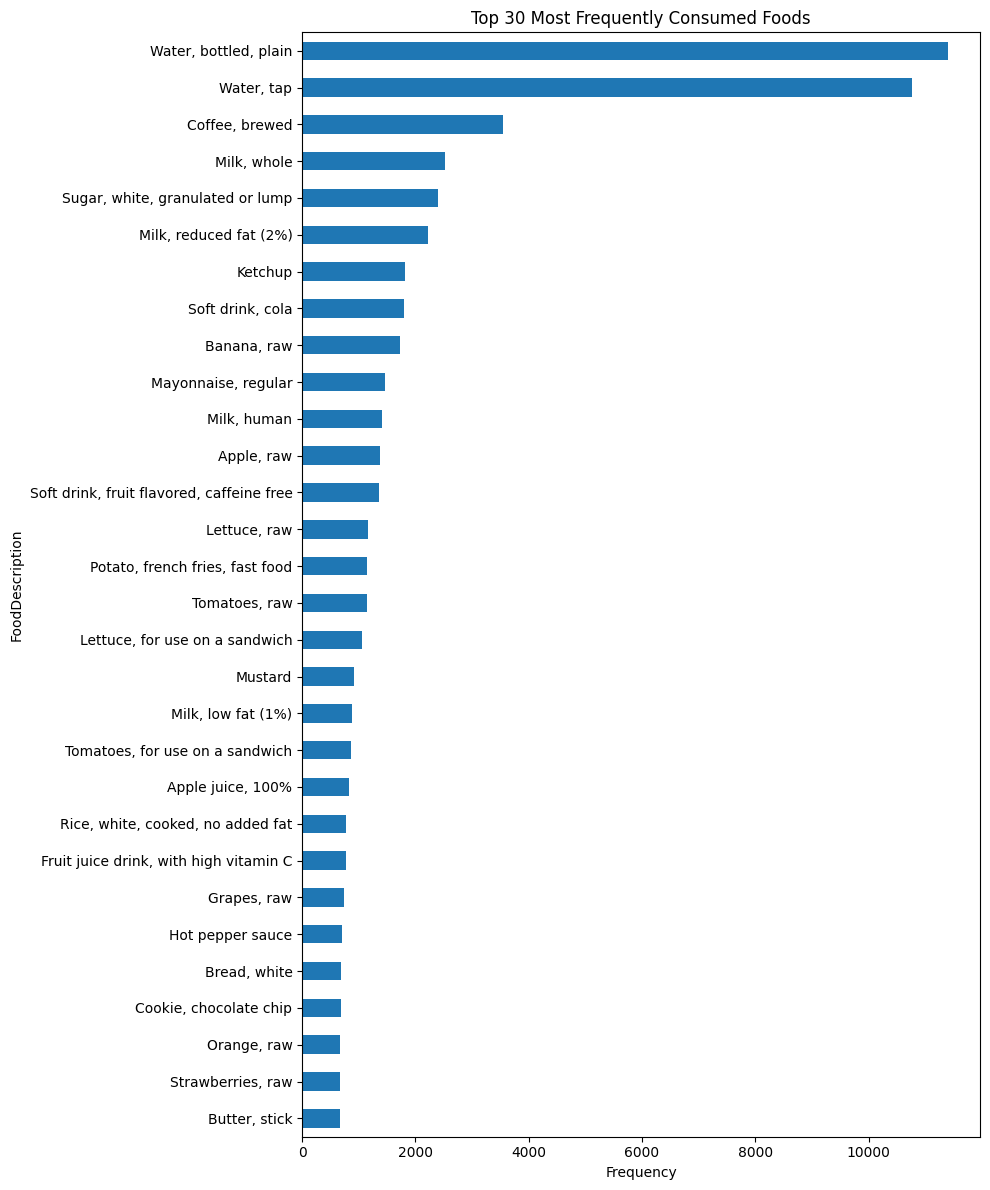

In [74]:
# ==========================================================
# PID11
# Top Foods
# ==========================================================

top_foods = (

food["FoodDescription"]

.value_counts()

.head(30)

)

plt.figure(figsize=(10,12))

top_foods.sort_values().plot.barh()

plt.title("Top 30 Most Frequently Consumed Foods")

plt.xlabel("Frequency")

plt.tight_layout()

plt.show()

In [75]:
# ==========================================================
# PID12
# Classify Foods into Major Food Groups
# ==========================================================

def classify_food(description):

    if pd.isna(description):
        return "Other"

    description = str(description).lower()

    # Water
    if "water" in description:
        return "Water"

    # Coffee
    elif "coffee" in description:
        return "Coffee"

    # Tea
    elif "tea" in description:
        return "Tea"

    # Dairy
    elif any(x in description for x in [
        "milk","cheese","yogurt","butter","cream"
    ]):
        return "Dairy"

    # Fruits
    elif any(x in description for x in [
        "apple","banana","orange","grape","pear",
        "pineapple","berry","melon","papaya",
        "fruit"
    ]):
        return "Fruit"

    # Vegetables
    elif any(x in description for x in [
        "broccoli","carrot","spinach","lettuce",
        "cabbage","tomato","onion","cucumber",
        "vegetable","salad","beans","peas"
    ]):
        return "Vegetables"

    # Fish & Seafood
    elif any(x in description for x in [
        "fish","salmon","tuna","cod",
        "shrimp","crab","prawn"
    ]):
        return "Fish"

    # Poultry
    elif any(x in description for x in [
        "chicken","turkey"
    ]):
        return "Poultry"

    # Red Meat
    elif any(x in description for x in [
        "beef","pork","lamb"
    ]):
        return "Red Meat"

    # Fast Food
    elif any(x in description for x in [
        "pizza","burger","sandwich",
        "hot dog","fries","fast food"
    ]):
        return "Fast Food"

    # Sweet Foods
    elif any(x in description for x in [
        "cake","cookie","chocolate",
        "candy","ice cream","sweet"
    ]):
        return "Sweets"

    # Soft Drinks
    elif any(x in description for x in [
        "cola","soft drink","soda",
        "pepsi","coca"
    ]):
        return "Soft Drinks"

    # Fruit Juice
    elif "juice" in description:
        return "Fruit Juice"

    # Breakfast Cereals
    elif any(x in description for x in [
        "cereal","corn flakes","granola","oats"
    ]):
        return "Breakfast Cereal"

    else:
        return "Other"


food["FoodGroup"] = food["FoodDescription"].apply(classify_food)

print("Food Classification Completed")

Food Classification Completed


In [76]:
# ==========================================================
# PID13
# Verify Food Classification
# ==========================================================

food[["FoodDescription","FoodGroup"]].sample(
    30,
    random_state=42
)

,FoodDescription,FoodGroup
75371,"Milk, human",Dairy
145621,"Water, tap",Water
14956,"Chicken breast, fried, coated, skin / coating ...",Poultry
57028,"Tea, hot, herbal",Tea
27444,"Popcorn, ready-to-eat, plain",Other
132275,"Cake or cupcake, white with white icing, from mix",Sweets
129639,"Doughnut, yeast type, with chocolate icing",Sweets
85989,"Cookie, butter or sugar",Dairy
94708,"Pasta with cream sauce and added vegetables, f...",Dairy
70731,"Potato chips, reduced fat",Other


FoodGroup
Other               49091
Dairy               30931
Water               26015
Fruit               16213
Vegetables          15809
Sweets               8372
Coffee               7280
Fast Food            6665
Poultry              6417
Tea                  4557
Soft Drinks          3752
Red Meat             3494
Breakfast Cereal     3178
Fish                 1541
Fruit Juice           595
Name: count, dtype: int64


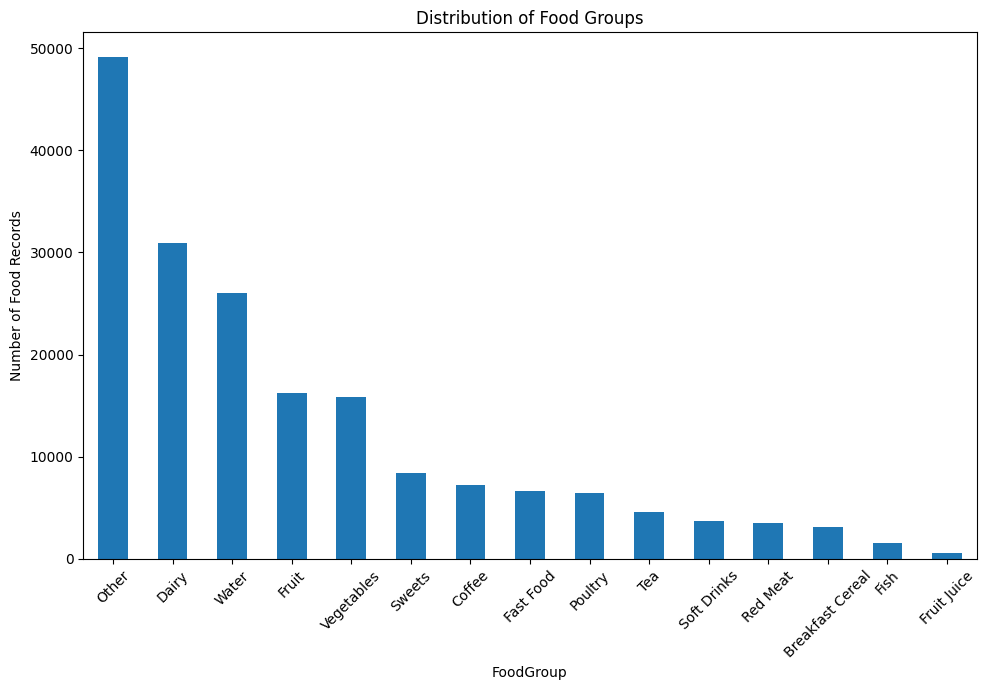

In [77]:
# ==========================================================
# PID14
# Food Group Distribution
# ==========================================================

food_group_counts = (

    food["FoodGroup"]

    .value_counts()

)

print(food_group_counts)

plt.figure(figsize=(10,7))

food_group_counts.plot.bar()

plt.title("Distribution of Food Groups")

plt.ylabel("Number of Food Records")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [78]:
# ==========================================================
# PID15
# Create Participant-Level Food Features
# ==========================================================

food_features = pd.crosstab(

    food["SEQN"],

    food["FoodGroup"]

)

food_features.head()

FoodGroup,Breakfast Cereal,Coffee,Dairy,Fast Food,Fish,Fruit,Fruit Juice,Other,Poultry,Red Meat,Soft Drinks,Sweets,Tea,Vegetables,Water
SEQN,,,,,,,,,,,,,,,
109263,0,0,2,0,0,1,0,3,0,0,0,3,0,1,3
109264,0,0,2,0,0,0,0,5,1,0,0,2,0,3,6
109265,0,0,4,0,0,2,0,1,2,0,0,2,0,2,4
109266,0,0,1,0,0,1,0,2,0,0,0,1,0,0,3
109269,0,0,2,1,0,3,0,2,0,0,0,0,0,0,0


In [79]:
# ==========================================================
# PID16
# Convert Counts to Binary
# ==========================================================

food_features = (

    food_features > 0

).astype(int)

food_features.reset_index(inplace=True)

print(food_features.shape)

food_features.head()

(12632, 16)


FoodGroup,SEQN,Breakfast Cereal,Coffee,Dairy,Fast Food,Fish,Fruit,Fruit Juice,Other,Poultry,Red Meat,Soft Drinks,Sweets,Tea,Vegetables,Water
0,109263,0,0,1,0,0,1,0,1,0,0,0,1,0,1,1
1,109264,0,0,1,0,0,0,0,1,1,0,0,1,0,1,1
2,109265,0,0,1,0,0,1,0,1,1,0,0,1,0,1,1
3,109266,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1
4,109269,0,0,1,1,0,1,0,1,0,0,0,0,0,0,0


In [80]:
# ==========================================================
# PID17
# Merge Food Features
# ==========================================================

master = pd.read_csv(

"C:/Users/kalya/NTCC/NHANES/CVD_ML_python/Outputs/ML_ready_dataset.csv"

)

master = master.merge(

    food_features,

    on="SEQN",

    how="left"

)

food_columns = food_features.columns.drop("SEQN")

master[food_columns] = (

    master[food_columns]

    .fillna(0)

    .astype(int)

)

print(master.shape)

master.head()

(15457, 658)


,SEQN,SDMVPSU,SDMVSTRA,WTINTPRP,WTMECPRP,RIAGENDR,RIDAGEYR,RIDRETH1,RIDRETH3,DMDEDUC2,DMDMARTZ,INDFMPIR,MCQ160A,MCQ160M,MCQ160P,MCQ160L,BPQ020,BPQ030,BPQ040A,BPQ050A,BPQ080,BPQ090D,BPQ100D,BPXOSY1,BPXOSY2,BPXOSY3,BPXODI1,BPXODI2,BPXODI3,LBXGLU,LBXGH,LBXIN,LBXTC,LBDLDL,LBDHDD,LBXTR,BMXWT,BMXHT,BMXBMI,BMXWAIST,BMXHIP,DR1TNUMF,DR1TKCAL,DR1TPROT,DR1TCARB,DR1TSUGR,DR1TFIBE,DR1TTFAT,DR1TSFAT,DR1TMFAT,DR1TPFAT,DR1TCHOL,DR1TATOC,DR1TATOA,DR1TRET,DR1TVARA,DR1TACAR,DR1TBCAR,DR1TCRYP,DR1TLYCO,DR1TLZ,DR1TVB1,DR1TVB2,DR1TNIAC,DR1TVB6,DR1TFOLA,DR1TFA,DR1TFF,DR1TFDFE,DR1TCHL,DR1TVB12,DR1TB12A,DR1TVC,DR1TVD,DR1TVK,DR1TCALC,DR1TPHOS,DR1TMAGN,DR1TIRON,DR1TZINC,DR1TCOPP,DR1TSODI,DR1TPOTA,DR1TSELE,DR1TCAFF,DR1TTHEO,DR1TALCO,DR1TMOIS,DR1TS040,DR1TS060,DR1TS080,DR1TS100,DR1TS120,DR1TS140,DR1TS160,DR1TS180,DR1TM161,DR1TM181,DR1TM201,DR1TM221,DR1TP182,DR1TP183,DR1TP184,DR1TP204,DR1TP205,DR1TP225,DR1TP226,DR1TWSZ,DR2TNUMF,DR2TKCAL,DR2TPROT,DR2TCARB,DR2TSUGR,DR2TFIBE,DR2TTFAT,DR2TSFAT,DR2TMFAT,DR2TPFAT,DR2TCHOL,DR2TATOC,DR2TATOA,DR2TRET,DR2TVARA,DR2TACAR,DR2TBCAR,DR2TCRYP,DR2TLYCO,DR2TLZ,DR2TVB1,DR2TVB2,DR2TNIAC,DR2TVB6,DR2TFOLA,DR2TFA,DR2TFF,DR2TFDFE,DR2TCHL,DR2TVB12,DR2TB12A,DR2TVC,DR2TVD,DR2TVK,DR2TCALC,DR2TPHOS,DR2TMAGN,DR2TIRON,DR2TZINC,DR2TCOPP,DR2TSODI,DR2TPOTA,DR2TSELE,DR2TCAFF,DR2TTHEO,DR2TALCO,DR2TMOIS,DR2TS040,DR2TS060,DR2TS080,DR2TS100,DR2TS120,DR2TS140,DR2TS160,DR2TS180,DR2TM161,DR2TM181,DR2TM201,DR2TM221,DR2TP182,DR2TP183,DR2TP184,DR2TP204,DR2TP205,DR2TP225,DR2TP226,DR2TWSZ,DSQTKCAL,DSQTPROT,DSQTCARB,DSQTSUGR,DSQTFIBE,DSQTTFAT,DSQTSFAT,DSQTMFAT,DSQTPFAT,DSQTCHOL,DSQTLYCO,DSQTLZ,DSQTVB1,DSQTVB2,DSQTNIAC,DSQTVB6,DSQTFA,DSQTFDFE,DSQTCHL,DSQTVB12,DSQTVC,DSQTVK,DSQTVD,DSQTCALC,DSQTPHOS,DSQTMAGN,DSQTIRON,DSQTZINC,DSQTCOPP,DSQTSODI,DSQTPOTA,DSQTSELE,DSQTCAFF,DSQTIODI,SMQ020,SMD030,SMQ040,SMQ050Q,SMQ050U,SMD057,SMQ078,SMD641,SMD650,SMD100FL,SMD100MN,SMQ670,SMQ621,SMD630,SMD460,SMD470,SMQ681,SMQ690A,SMQ710,SMQ720,SMQ725,SMQ690B,SMQ740,SMQ690C,SMQ770,SMQ690G,SMQ845,SMQ690H,SMQ849,SMQ851,SMQ690D,SMQ800,SMQ690E,SMQ817,SMQ690K,SMQ863,SMQ690F,SMQ830,SMDANY,SMQ856,SMQ858,SMQ860,SMQ862,SMQ866,SMQ868,SMQ870,SMQ872,SMQ874,SMQ876,SMQ878,SMQ880,SMQ940,ALQ111,ALQ121,ALQ130,ALQ142,ALQ270,ALQ280,ALQ290,ALQ151,ALQ170,PAQ605,PAQ610,PAD615,PAQ620,PAQ625,PAD630,PAQ635,PAQ640,PAD645,PAQ650,PAQ655,PAD660,PAQ665,PAQ670,PAD675,PAD680,PAQ706,LBXCOT,LBXHCOT,URXBCPP,URXBCEP,URXBDCP,URXDBUP,URXDPHP,LBXBPB,LBXBCD,LBXTHG,LBXBSE,LBXBMN,LBXPFDE,LBXPFHS,LBXPFNA,LBXPFUA,LBXNFOA,LBXBFOA,LBXNFOS,LBXMFOS,URXUAS3,URXUAS5,URXUHG,URXUBA,URXUCD,URXUCO,URXUPB,URXUSB,URXUTL,URXUTU,URXUAS,MCQ300A,MCQ300B,MCQ300C,SMQ690A_WASMISSING,SMQ690B_WASMISSING,SMQ690C_WASMISSING,SMQ690G_WASMISSING,SMQ690H_WASMISSING,SMQ690D_WASMISSING,SMQ690E_WASMISSING,SMQ690K_WASMISSING,SMQ690F_WASMISSING,SMD030_WASMISSING,SMD057_WASMISSING,SMD641_WASMISSING,SMD650_WASMISSING,SMD100FL_WASMISSING,SMD100MN_WASMISSING,SMD630_WASMISSING,SMD460_WASMISSING,SMD470_WASMISSING,ALQ121_WASMISSING,ALQ130_WASMISSING,ALQ142_WASMISSING,ALQ270_WASMISSING,ALQ280_WASMISSING,ALQ290_WASMISSING,ALQ151_WASMISSING,ALQ170_WASMISSING,PAD615_WASMISSING,PAD630_WASMISSING,PAD645_WASMISSING,PAD660_WASMISSING,PAD675_WASMISSING,PAD680_WASMISSING,DSQTKCAL_WASMISSING,DSQTPROT_WASMISSING,DSQTCARB_WASMISSING,DSQTSUGR_WASMISSING,DSQTFIBE_WASMISSING,DSQTTFAT_WASMISSING,DSQTSFAT_WASMISSING,DSQTMFAT_WASMISSING,DSQTPFAT_WASMISSING,DSQTCHOL_WASMISSING,DSQTLYCO_WASMISSING,DSQTLZ_WASMISSING,DSQTVB1_WASMISSING,DSQTVB2_WASMISSING,DSQTNIAC_WASMISSING,DSQTVB6_WASMISSING,DSQTFA_WASMISSING,DSQTFDFE_WASMISSING,DSQTCHL_WASMISSING,DSQTVB12_WASMISSING,DSQTVC_WASMISSING,DSQTVK_WASMISSING,DSQTVD_WASMISSING,DSQTCALC_WASMISSING,DSQTPHOS_WASMISSING,DSQTMAGN_WASMISSING,DSQTIRON_WASMISSING,DSQTZINC_WASMISSING,DSQTCOPP_WASMISSING,DSQTSODI_WASMISSING,DSQTPOTA_WASMISSING,DSQTSELE_WASMISSING,DSQTCAFF_WASMISSING,DSQTIODI_WASMISSING,SMQ050Q_WASMISSING,SMQ050U_WASMISSING,SMQ078_WASMISSING,SMQ670_WASMISSING,SMQ710_WASMISSING,SMQ720_WASMISSING,SMQ725_WASMISSING,SMQ740_WASMISSING,SM

In [81]:
# ==========================================================
# PID18
# Save Enhanced Dataset
# ==========================================================

master.to_csv(

"C:/Users/kalya/NTCC/NHANES/CVD_ML_python/Outputs/ML_READY_DATASET_FOOD.csv",

index=False

)

print("Enhanced dataset saved successfully.")

Enhanced dataset saved successfully.


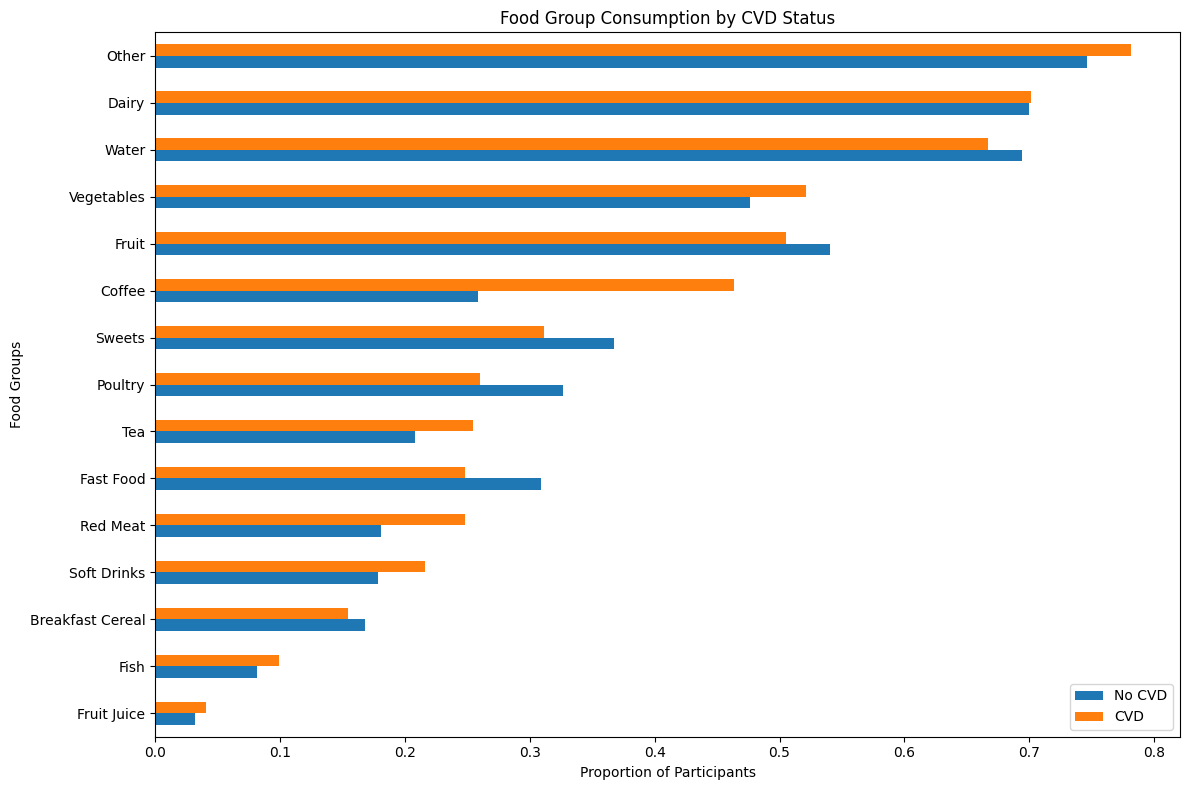

,No CVD,CVD
Breakfast Cereal,0.168306,0.154529
Coffee,0.258740,0.463588
Dairy,0.699742,0.701599
Fast Food,0.309329,0.247780
Fish,0.081502,0.099467
Fruit,0.540646,0.505329
Fruit Juice,0.032238,0.040853
Other,0.746494,0.781528
Poultry,0.326635,0.260213
Red Meat,0.181216,0.247780


In [82]:
# ==========================================================
# PID19
# Food Group Consumption by CVD Status
# ==========================================================

comparison = (
    master
    .groupby("Composite_CVD")[food_columns]
    .mean()
    .T
)

comparison.columns = ["No CVD", "CVD"]

comparison.sort_values("CVD").plot(
    kind="barh",
    figsize=(12,8)
)

plt.title("Food Group Consumption by CVD Status")
plt.xlabel("Proportion of Participants")
plt.ylabel("Food Groups")

plt.tight_layout()

plt.show()

comparison

In [83]:
# ==========================================================
# PID20
# Difference Between Groups
# ==========================================================

comparison["Difference"] = comparison["CVD"] - comparison["No CVD"]

comparison = comparison.sort_values(
    by="Difference",
    ascending=False
)

comparison

,No CVD,CVD,Difference
Coffee,0.258740,0.463588,0.204848
Red Meat,0.181216,0.247780,0.066564
Tea,0.208220,0.254885,0.046665
Vegetables,0.476171,0.521314,0.045144
Soft Drinks,0.178773,0.215808,0.037035
Other,0.746494,0.781528,0.035034
Fish,0.081502,0.099467,0.017966
Fruit Juice,0.032238,0.040853,0.008615
Dairy,0.699742,0.701599,0.001857
Breakfast Cereal,0.168306,0.154529,-0.013777


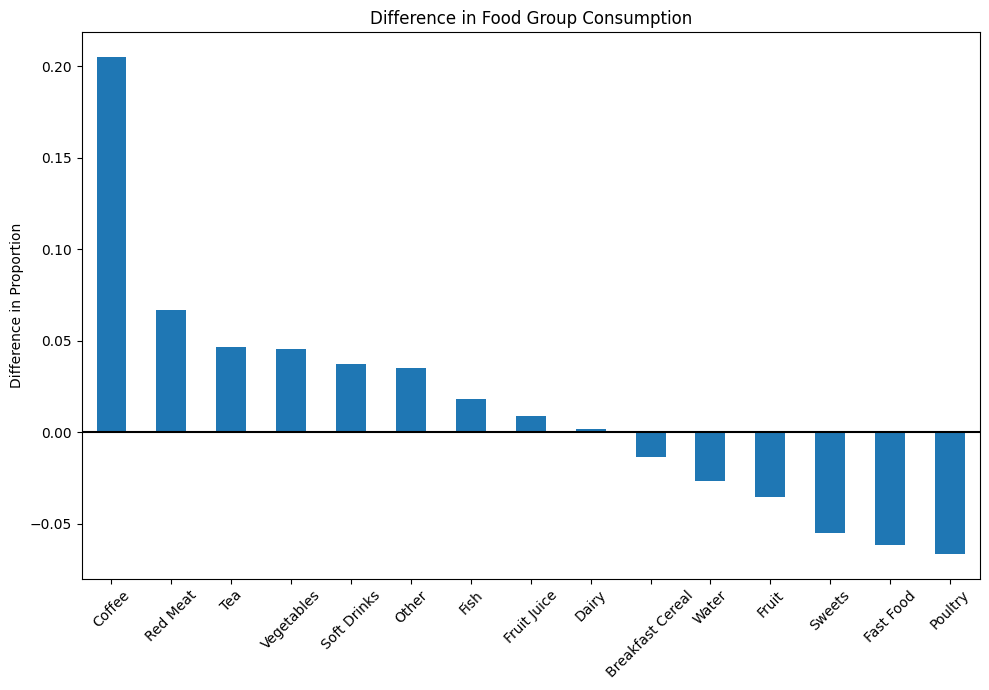

In [84]:
# ==========================================================
# PID21
# Difference Plot
# ==========================================================

plt.figure(figsize=(10,7))

comparison["Difference"].plot(
    kind="bar"
)

plt.axhline(0,color="black")

plt.ylabel("Difference in Proportion")

plt.title("Difference in Food Group Consumption")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [85]:
# ==========================================================
# PID22
# Chi-Square Test
# ==========================================================

from scipy.stats import chi2_contingency

results = []

for col in food_columns:

    table = pd.crosstab(
        master[col],
        master["Composite_CVD"]
    )

    chi2,p,dof,expected = chi2_contingency(table)

    results.append({

        "Food Group":col,

        "Chi Square":chi2,

        "P Value":p

    })

chi_results = pd.DataFrame(results)

chi_results = chi_results.sort_values(
    "P Value"
)

chi_results

,Food Group,Chi Square,P Value
1,Coffee,219.364750,1.244368e-49
9,Red Meat,30.105464,4.091767e-08
8,Poultry,20.800767,5.096255e-06
3,Fast Food,18.373618,1.815544e-05
11,Sweets,13.608847,2.251221e-04
12,Tea,13.347895,2.587129e-04
10,Soft Drinks,9.392128,2.179191e-03
13,Vegetables,8.344804,3.867918e-03
7,Other,6.631442,1.001941e-02
5,Fruit,5.097966,2.395391e-02


In [86]:
# ==========================================================
# PID23
# Significant Food Groups
# ==========================================================

significant = chi_results[
    chi_results["P Value"] < 0.05
]

print(significant)

significant

     Food Group  Chi Square       P Value
1        Coffee  219.364750  1.244368e-49
9      Red Meat   30.105464  4.091767e-08
8       Poultry   20.800767  5.096255e-06
3     Fast Food   18.373618  1.815544e-05
11       Sweets   13.608847  2.251221e-04
12          Tea   13.347895  2.587129e-04
10  Soft Drinks    9.392128  2.179191e-03
13   Vegetables    8.344804  3.867918e-03
7         Other    6.631442  1.001941e-02
5         Fruit    5.097966  2.395391e-02
4          Fish    4.202954  4.035363e-02


,Food Group,Chi Square,P Value
1,Coffee,219.364750,1.244368e-49
9,Red Meat,30.105464,4.091767e-08
8,Poultry,20.800767,5.096255e-06
3,Fast Food,18.373618,1.815544e-05
11,Sweets,13.608847,2.251221e-04
12,Tea,13.347895,2.587129e-04
10,Soft Drinks,9.392128,2.179191e-03
13,Vegetables,8.344804,3.867918e-03
7,Other,6.631442,1.001941e-02
5,Fruit,5.097966,2.395391e-02


In [87]:
# ==========================================================
# PID24
# Save Results
# ==========================================================

chi_results.to_csv(

"C:/Users/kalya/NTCC/NHANES/CVD_ML_python/Outputs/Food_Group_ChiSquare.csv",

index=False

)

comparison.to_csv(

"C:/Users/kalya/NTCC/NHANES/CVD_ML_python/Outputs/Food_Group_Comparison.csv"

)

print("Statistical analysis saved successfully.")

Statistical analysis saved successfully.


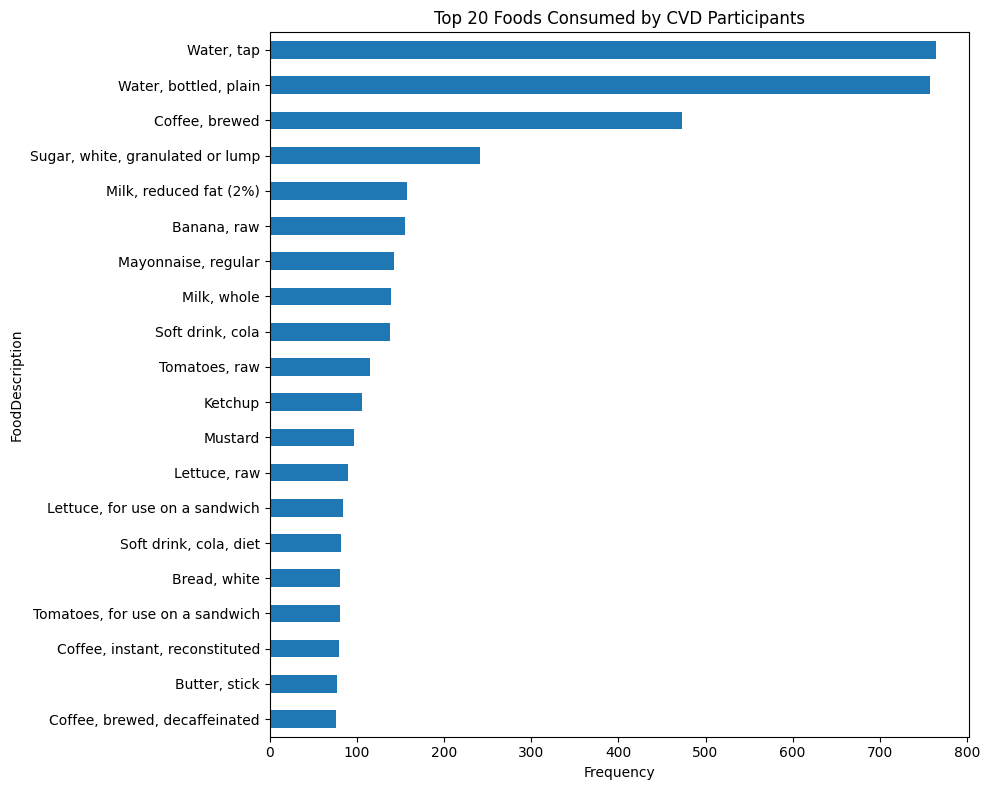

In [88]:
# ==========================================================
# PID25
# Top Foods in CVD Participants
# ==========================================================

cvd_ids = master.loc[
    master["Composite_CVD"] == 1,
    "SEQN"
]

top_cvd_foods = (
    food[food["SEQN"].isin(cvd_ids)]
    ["FoodDescription"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(10,8))

top_cvd_foods.sort_values().plot.barh()

plt.title("Top 20 Foods Consumed by CVD Participants")

plt.xlabel("Frequency")

plt.tight_layout()

plt.show()

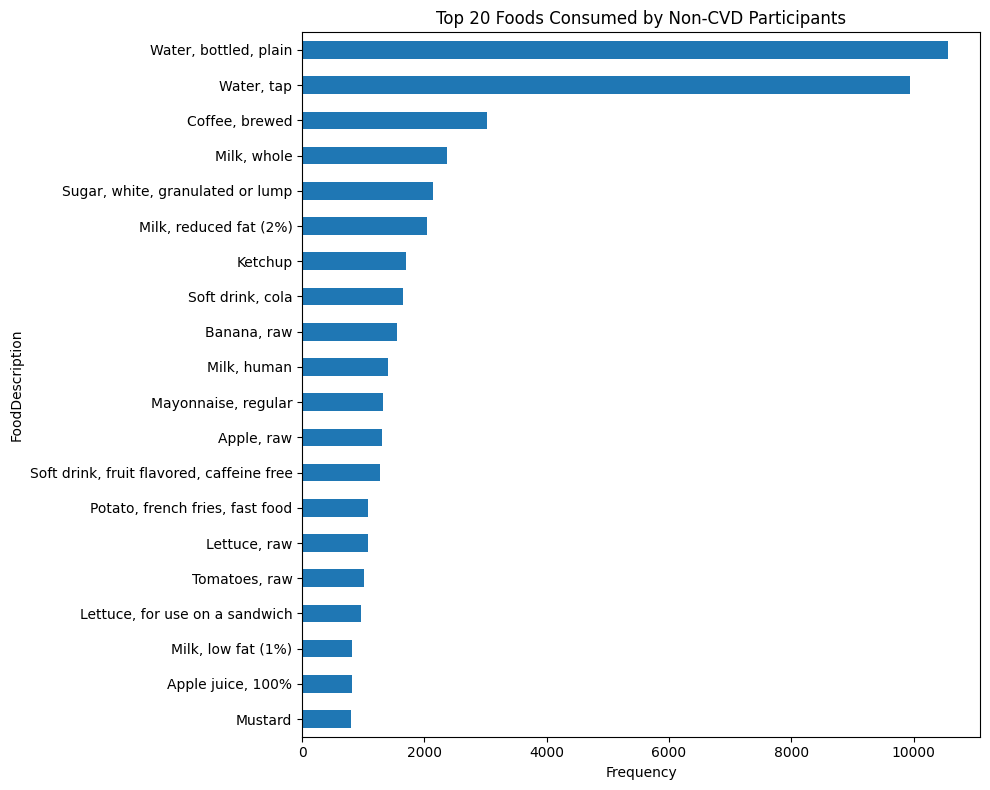

In [89]:
# ==========================================================
# PID26
# Top Foods in Non-CVD Participants
# ==========================================================

non_cvd_ids = master.loc[
    master["Composite_CVD"] == 0,
    "SEQN"
]

top_non_cvd_foods = (
    food[food["SEQN"].isin(non_cvd_ids)]
    ["FoodDescription"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(10,8))

top_non_cvd_foods.sort_values().plot.barh()

plt.title("Top 20 Foods Consumed by Non-CVD Participants")

plt.xlabel("Frequency")

plt.tight_layout()

plt.show()